# US Disaster Analytics Toolkit.

### INFO 153 Final Project

#### Team Members:
- Shaine Magliulo    ID: sm4823
- Tyler Dougherty    ID: td845
- Selim Atambaev     ID: sa4252
- Michael Governanti ID: mag574


This project analyzes FEMA disaster declaration data using Python, SQLite, SQL queries, and data visualizations to identify disaster trends across the United States.

---

## Project Overview

For our project, we wanted to work with real-world data that could be analyzed in multiple ways. This data could be used to solve real-world disaster-related problems, identify trends, and save lives. We chose FEMA disaster declaration data because it contains information about disasters across the United States over the past 60 years. Our goal was to take raw FEMA CSV data and turn it into something easier to search, organize, and visualize using Python, SQLite, SQL queries, and charts.

## Data Source

The dataset used in this project comes from FEMA Disaster Declaration Summaries. FEMA stands for the Federal Emergency Management Agency. It is a federal agency under the U.S. Department of Homeland Security tasked with coordinating the federal government's response to natural and man-made disasters that overwhelm the resources of local and state authorities. The CSV file contains information about disaster declarations such as disaster number, state, declaration type, declaration date, fiscal year, incident type, designated area, and FEMA region.

The full data source can be found here: https://www.fema.gov/openfema-data-page/disaster-declarations-summaries-v2

## Business Problem

Raw disaster datasets can be difficult to read and analyze manually, especially when dealing with thousands of records. Emergency planners, researchers, and government agencies may need a faster way to identify disaster trends by year, state, or disaster type. This project helps solve that problem by organizing FEMA disaster data into a searchable SQLite database and generating summaries and visual charts from the data.

---

## Project Workflow

The overall workflow of the project is:

1. Load FEMA disaster declaration data from a CSV file
2. Inspect and normalize the data to a SQLite database
3. Create a Read Evaluate Print Loop style application to analyze the data
    - Use SQL queries to analyze the data
    - Generate charts and visualizations using matplotlib
    - Allow users to search disaster records

## How To Use This Notebook

Requirements to run:
- Python3 and Jupyter Notebook utilities
- Matplotlib Python library
- Pandas Python library
- SQLite
- ./scripts/DisasterDeclarationsSummaries.csv (data file)

Once the requirements are met the code within this notebook forms our application, you can press play on each codeblock or run the standalone Python scripts stored alongside this file.

If running the scripts, to recreate the database run `build_database.py` and to work with and query the data run `app.py`.

---

## Import Libraries

The project uses pandas for data processing, SQLite for database management, and matplotlib for data visualization.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sqlite3
import sys

## Inspect Source CSV File

We can explore the source data in its csv format to inspect the shape of our data before normalizing to a database for reliable storage and processing.

In [5]:
# Set the file path for the raw FEMA disaster data
csv_path = "./scripts/DisasterDeclarationsSummaries.csv"

# Read the FEMA CSV file into a pandas DataFrame
df = pd.read_csv(csv_path)

# Display the number of rows and columns in the dataset
print("Rows and columns:", df.shape)

# Display all column names from the FEMA dataset
print("\nColumn names:")
print(df.columns.tolist())

# Display the first 5 rows of the dataset
print("\nFirst 5 rows:")
print(df.head())

# Display the number of missing values in each column
print("\nMissing values:")
print(df.isnull().sum())



Rows and columns: (69898, 28)

Column names:
['femaDeclarationString', 'disasterNumber', 'state', 'declarationType', 'declarationDate', 'fyDeclared', 'incidentType', 'declarationTitle', 'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared', 'incidentBeginDate', 'incidentEndDate', 'disasterCloseoutDate', 'tribalRequest', 'fipsStateCode', 'fipsCountyCode', 'placeCode', 'designatedArea', 'declarationRequestNumber', 'lastIAFilingDate', 'incidentId', 'region', 'designatedIncidentTypes', 'lastRefresh', 'hash', 'id']

First 5 rows:
  femaDeclarationString  disasterNumber state declarationType  \
0            EM-3610-PR            3610    PR              EM   
1            FM-5529-OR            5529    OR              FM   
2            FM-5528-OR            5528    OR              FM   
3            FM-5527-OR            5527    OR              FM   
4            EM-3610-PR            3610    PR              EM   

            declarationDate  fyDeclared  incident

## Normalize to A SQLite Database

Now that we have a better understanding we can normalize the .csv to a relational database. Our team chose SQLite to allow a highly portable storage format so we could easily collaborate on the project and submit a complete workable application notebook.

In [6]:
# Set file paths for the raw FEMA data and the SQLite database
csv_path = "./scripts/DisasterDeclarationsSummaries.csv"
db_path = "disasters.db"

# Read the FEMA CSV file into a pandas DataFrame
df = pd.read_csv(csv_path)

# Connect to the SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Create database tables
cursor.execute("""
CREATE TABLE IF NOT EXISTS states (
    state_id INTEGER PRIMARY KEY AUTOINCREMENT,
    state_code TEXT UNIQUE
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS incident_types (
    incident_type_id INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_type TEXT UNIQUE
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS disasters (
    disaster_id INTEGER PRIMARY KEY,
    declaration_type TEXT,
    declaration_date TEXT,
    fy_declared INTEGER,
    declaration_title TEXT,
    state_id INTEGER,
    incident_type_id INTEGER,

    FOREIGN KEY(state_id) REFERENCES states(state_id),
    FOREIGN KEY(incident_type_id) REFERENCES incident_types(incident_type_id)
)
""")

# Insert unique state and jurisdiction codes
states = df["state"].dropna().unique()

for state in states:
    cursor.execute("""
    INSERT OR IGNORE INTO states (state_code)
    VALUES (?)
    """, (state,))

# Insert unique disaster incident types
incident_types = df["incidentType"].dropna().unique()

for incident in incident_types:
    cursor.execute("""
    INSERT OR IGNORE INTO incident_types (incident_type)
    VALUES (?)
    """, (incident,))

# Save state and incident type records before inserting disaster records
conn.commit()

# Insert disaster records
for _, row in df.iterrows():

    # Look up the matching state_id for this disaster record
    cursor.execute("""
    SELECT state_id FROM states
    WHERE state_code = ?
    """, (row["state"],))

    state_id = cursor.fetchone()[0]

    # Look up the matching incident_type_id for this disaster record
    cursor.execute("""
    SELECT incident_type_id FROM incident_types
    WHERE incident_type = ?
    """, (row["incidentType"],))

    incident_type_id = cursor.fetchone()[0]

    # Insert the disaster record using foreign keys instead of repeating text values
    cursor.execute("""
    INSERT OR IGNORE INTO disasters (
        disaster_id,
        declaration_type,
        declaration_date,
        fy_declared,
        declaration_title,
        state_id,
        incident_type_id
    )
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (
        int(row["disasterNumber"]),
        row["declarationType"],
        row["declarationDate"],
        int(row["fyDeclared"]),
        row["declarationTitle"],
        state_id,
        incident_type_id
    ))

# Save all disaster records and close the database connection
conn.commit()
conn.close()

## Create a "Toolkit" Read Evaluate Print Loop

A REPL allows us to quickly ask questions of our data.

** note: depending on Jupyter/ipykernel config this may not be interactive

In [ ]:
def print_rows(rows):
    # helper to print query responses
    if not rows:
        print("No results found.")
        return

    for row in rows:
        print(row)

def get_int(prompt, default=None):
    # helper to process user input to an integer
    value = input(prompt).strip()

    if value == "":
        return default

    try:
        return int(value)
    except ValueError:
        print("Please enter a valid number.")
        return get_int(prompt, default) # a little recursion as a treat ( ͡° ͜ʖ ͡°)

class App:
    """
    Application class for the disaster analysis REPL.

    This class manages the database connection, runs SQL queries,
    displays query results, and creates charts from the disaster data.
    """

    def __init__(self, dbpath):
        """
        Initialize the application with the path to the SQLite database.

        Validates the SQLite connection and sets the
        applications min and max year.
        """

        self.dbpath = dbpath
        self.min_year = 0
        self.max_year = 0
        self.limit = 10
        
        if not self.dbpath.exists():
            raise FileNotFoundError(f"Database not found: {self.dbpath}")

        try:
            with self.connect() as conn:
                self.min_year, self.max_year = self.db_year_range()
        except sqlite3.Error as e:
            raise RuntimeError(f"Could not connect to database: {e}")

    def connect(self):
        """
        Convenience wrapper for sqlite connection
        """

        return sqlite3.connect(self.dbpath)

    def disasters_by_year(self, start_year=None, end_year=None):
        """
        Return the number of disaster declarations for each year
        time sliced by start_year and end_year.
        """

        query = """
        SELECT 
            fy_declared AS year,
            COUNT(*) AS disaster_count
        FROM disasters
        WHERE fy_declared BETWEEN ? AND ?
        GROUP BY fy_declared
        ORDER BY fy_declared;
        """

        with self.connect() as conn:
            return conn.execute(query, (start_year, end_year)).fetchall()

    def disasters_by_state(self, start_year=None, end_year=None, limit=None):
        """
        Return disaster counts grouped by state, limited,
        and time sliced by start_year and end_year.
        """

        query = """
        SELECT 
            s.state_code,
            COUNT(*) AS disaster_count
        FROM disasters d
        JOIN states s ON d.state_id = s.state_id
        WHERE d.fy_declared BETWEEN ? AND ?
        GROUP BY s.state_code
        ORDER BY disaster_count DESC
        LIMIT ?;
        """

        with self.connect() as conn:
            return conn.execute(query, (start_year, end_year, limit)).fetchall()

    def disasters_by_type(self, start_year=None, end_year=None):
        """
        Return disaster counts grouped by incident type.
        """

        query = """
        SELECT 
            it.incident_type,
            COUNT(*) AS disaster_count
        FROM disasters d
        JOIN incident_types it ON d.incident_type_id = it.incident_type_id
        WHERE d.fy_declared BETWEEN ? AND ?
        GROUP BY it.incident_type
        ORDER BY disaster_count DESC;
        """

        with self.connect() as conn:
            return conn.execute(query, (start_year, end_year)).fetchall()

    def search_disasters(self, state=None, year=None, incident_type=None):
        """
        Search disaster declarations using optional state, year,
        and incident_type filters.
        """

        query = """
        SELECT
            d.disaster_id,
            d.declaration_title,
            d.declaration_type,
            d.declaration_date,
            d.fy_declared,
            s.state_code,
            it.incident_type
        FROM disasters d
        JOIN states s ON d.state_id = s.state_id
        JOIN incident_types it ON d.incident_type_id = it.incident_type_id
        WHERE 1 = 1
        """

        params = []

        if state is not None:
            query += " AND s.state_code = ?"
            params.append(state.upper())

        if year is not None:
            query += " AND d.fy_declared = ?"
            params.append(year)

        if incident_type is not None:
            query += " AND it.incident_type = ?"
            params.append(incident_type)

        query += " ORDER BY d.declaration_date DESC;"

        with self.connect() as conn:
            return conn.execute(query, params).fetchall()
    

    def chart_disasters_by_year(self, start_year=None, end_year=None):
        """
        Generate a simple chart of time sliced disasters by year.
        """

        rows = self.disasters_by_year(start_year, end_year)

        years = [row[0] for row in rows]
        counts = [row[1] for row in rows]

        plt.figure(figsize=(10, 5))
        plt.plot(years, counts, marker="o")
        plt.title(f"Declared Disasters by Year ({start_year}-{end_year})")
        plt.xlabel("Year")
        plt.ylabel("Number of Disasters")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def chart_top_states(self, start_year=None, end_year=None, limit=None):
        """
        Generate a chart of the states with the most disasters.
        """

        rows = self.disasters_by_state(start_year, end_year, limit)

        states = [row[0] for row in rows]
        counts = [row[1] for row in rows]

        plt.figure(figsize=(10, 5))
        plt.bar(states, counts)
        plt.title(f"Top {limit} States by Disaster Count ({start_year}-{end_year})")
        plt.xlabel("State")
        plt.ylabel("Number of Disasters")
        plt.tight_layout()
        plt.show()

    def db_year_range(self):
        """
        Convenience function to populate the application with
        min and max years.
        """

        query = """
        SELECT
            MIN(fy_declared),
            MAX(fy_declared)
        FROM disasters;
        """

        with self.connect() as conn:
            return conn.execute(query).fetchone()

    def REPL(self):
        """
        Run a Read Evaluate Print Loop(REPL) to allow iterative querying of disaster data.
        The REPL displays a menu, asks the user to choose an option andperforms the appropriate action.
        """

        helptext = """
Disaster Analysis CLI

1. Show disasters by year
2. Show top states by disaster count
3. Show disasters by type
4. Search disasters
5. Chart disasters by year
6. Chart top states
7. Exit
"""
        startyeartext = f"Start year [default {self.min_year}]: "
        endyeartext = f"End year [default {self.max_year}]: "
        limittext = f"Limit [default {self.limit}]: "

        while True:
            print(helptext)

            selection = input("Choose an option: ").strip()
            match selection:
                case "1":
                    # Show disasters by year
                    start_year = get_int(startyeartext, self.min_year)
                    end_year = get_int(endyeartext, self.max_year)

                    rows = self.disasters_by_year(start_year, end_year)

                    print("\nYear | Count")
                    print("------------")
                    for year, count in rows:
                        print(f"{year} | {count}")

                case "2":
                    # Show top states by disaster count
                    start_year = get_int(startyeartext, self.min_year)
                    end_year = get_int(endyeartext, self.max_year)
                    limit = get_int(limittext, self.limit)

                    rows = self.disasters_by_state(start_year, end_year, limit)

                    print("\nState | Count")
                    print("-------------")
                    for state, count in rows:
                        print(f"{state} | {count}")

                case "3":
                    # Show disasters by type
                    start_year = get_int(startyeartext, self.min_year)
                    end_year = get_int(endyeartext, self.max_year)

                    rows = self.disasters_by_type(start_year, end_year)

                    print("\nIncident Type | Count")
                    print("---------------------")
                    for incident_type, count in rows:
                        print(f"{incident_type} | {count}")

                case "4":
                    # Search disasters
                    state = input("State code [default all]: ").strip()
                    year = get_int("Year [default all]: ", None)
                    incident_type = input("Incident type [default all]: ").strip()

                    if state == "":
                        state = None

                    if incident_type == "":
                        incident_type = None

                    rows = self.search_disasters(
                        state=state,
                        year=year,
                        incident_type=incident_type,
                    )

                    print("\nSearch Results")
                    print("--------------")
                    for row in rows:
                        print(row)

                case "5":
                    # Chart disasters by year
                    start_year = get_int(startyeartext, self.min_year)
                    end_year = get_int(endyeartext, self.max_year)

                    self.chart_disasters_by_year(start_year, end_year)

                case "6":
                    # Chart top states
                    start_year = get_int(startyeartext, self.min_year)
                    end_year = get_int(endyeartext, self.max_year)
                    limit = get_int(limittext, self.limit)

                    self.chart_top_states(start_year, end_year, limit)

                case "7":
                    # Exit
                    print("Goodbye.")
                    break

                case _:
                    # Invalid choice
                    print("Invalid choice. Please choose 1-7.")

def main(dbpath):
    App(dbpath).REPL()

if __name__ == "__main__":
    dbpath = Path("disasters.db")
    if len(sys.argv) > 1:
        dbpath = Path(sys.argv[1])
    main(dbpath)


Disaster Analysis CLI

1. Show disasters by year
2. Show top states by disaster count
3. Show disasters by type
4. Search disasters
5. Chart disasters by year
6. Chart top states
7. Exit



### 1. Show disasters by year

```
Choose an option: 1
Start year [default 1953]: 2010
End year [default 2026]: 2026

Year | Count
------------
2010 | 109
2011 | 236
2012 | 103
2013 | 111
2014 | 85
2015 | 78
2016 | 84
2017 | 135
2018 | 132
2019 | 102
2020 | 315
2021 | 123
2022 | 98
2023 | 114
2024 | 162
2025 | 143
2026 | 53
```

### 2. Show top states by disaster count

```
Choose an option: 2
Start year [default 1953]: 
End year [default 2026]: 
Limit [default 10]: 

State | Count
-------------
CA | 392
TX | 386
OK | 258
WA | 213
FL | 188
OR | 166
NM | 125
AZ | 119
NY | 118
NV | 110
```

### 3. Show disasters by type

```
Choose an option: 3    
Start year [default 1953]: 2005
End year [default 2026]: 2026

Incident Type | Count
---------------------
Fire | 1133
Severe Storm | 728
Hurricane | 293
Flood | 249
Biological | 167
Snowstorm | 68
Severe Ice Storm | 47
Tropical Storm | 37
Tornado | 33
Winter Storm | 32
Coastal Storm | 15
Other | 14
Earthquake | 13
Typhoon | 12
Mud/Landslide | 11
Straight-Line Winds | 5
Tsunami | 3
Dam/Levee Break | 3
Volcanic Eruption | 2
Freezing | 2
Tropical Depression | 1
Toxic Substances | 1
Terrorist | 1
Drought | 1
Chemical | 1
```

### 4. Search disasters

```
Choose an option: 4   
State code [default all]: PA
Year [default all]: 2020
Incident type [default all]: 

Search Results
--------------
(4506, 'COVID-19 PANDEMIC', 'DR', '2020-03-30T00:00:00.000Z', 2020, 'PA', 'Biological')
(3441, 'COVID-19 ', 'EM', '2020-03-13T00:00:00.000Z', 2020, 'PA', 'Biological')
```

### 5. Chart disasters by year

```
Choose an option: 5
Start year [default 1953]: 2000
End year [default 2026]: 2026
```

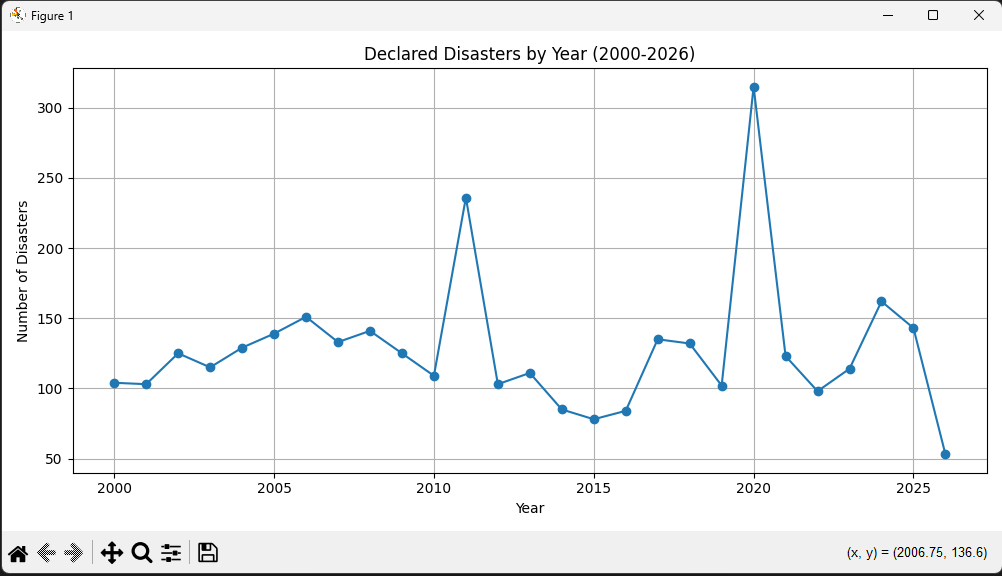

### 6. Chart top states

```
Choose an option: 6
Start year [default 1953]: 2008
End year [default 2026]: 2020
Limit [default 10]: 10
```

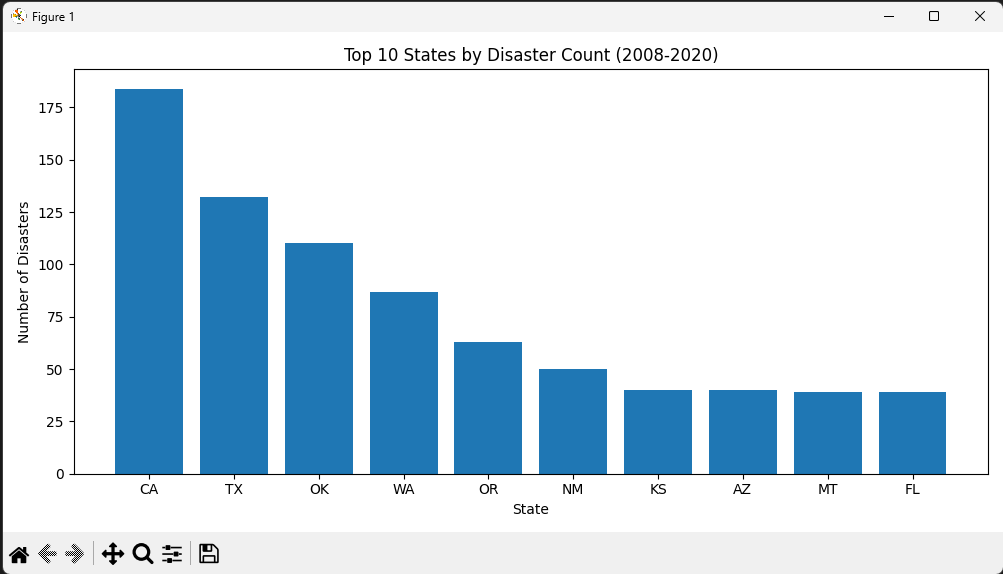

### 7. Exit

```
Choose an option: 7
Goodbye.
```

---

## Data Processing

The original FEMA CSV file was imported into Python using pandas. We selected the columns that were most useful for analysis and renamed some columns to make them easier to work with in SQL queries. After cleaning the data, we stored it inside a SQLite database so it could be queried more efficiently. SQL queries were then used to group, filter, and summarize disaster information.

---

## Underlying Data Structure

The project uses a relational data structure stored in a SQLite database. The original FEMA disaster declaration CSV is transformed into three related tables: disasters, states, and incident_types.

Each row in the disasters table represents a FEMA disaster declaration record. The main fields stored for each disaster include the disaster ID, declaration type, declaration date, fiscal year declared, declaration title, state reference, and incident type reference.

State codes and incident types are stored in separate tables to reduce repeated text values. The disasters table uses foreign keys to connect each disaster record to its matching state and incident type.

---

## Technologies Used

This project was developed using the following technologies:

- Python
- pandas
- SQLite
- matplotlib
- Jupyter Notebook

---

## Observations

Based on the analysis, disaster declarations generally increased over time. Certain years showed major spikes in disaster activity, which seem to be related to large-scale hurricanes, storms, and national emergencies. The analysis also showed that some states consistently experience more disaster declarations than others.

---

## Challenges Faced

One challenge during the project was configuring package installations within the hosted JupyterHub environment. Another challenge involved cleaning and organizing a large dataset into a format that worked well with SQLite and SQL queries. Additional time was spent troubleshooting database connections and visualization formatting.

---

## Conclusion

This project demonstrates how Python, SQLite, SQL, and data visualization tools can be used together to process and analyze real-world datasets.

By importing FEMA disaster declaration data from a CSV file into a database, we were able to organize the data, run SQL queries, and create charts that help visualize disaster trends across the United States. We believe that this tool can be used to mitiage future disasters and potentially save an untold number of human lives in the process.